In [3]:
import pandas as pd
houses = pd.read_csv('../data/kc_house_data.csv', parse_dates=['date'])

In [6]:
span = houses.date.max() - houses.date.min()
span.days

390

In [58]:
date = houses.date.value_counts().head(1) #.mode()[0]
date = date.index[0]
date

Timestamp('2014-06-23 00:00:00')

In [59]:
houses[houses.date == date]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
117,4060000240,2014-06-23,205425.0,2,1.00,880,6780,1.0,0,0,...,6,880,0,1945,0,98178,47.5009,-122.248,1190,6780
397,5175800060,2014-06-23,365000.0,4,2.00,1940,25600,1.0,0,0,...,8,1940,0,1962,0,98006,47.5722,-122.129,2000,10071
470,2172000075,2014-06-23,290900.0,2,2.00,1610,17600,2.0,0,0,...,6,1610,0,1930,1983,98178,47.4855,-122.266,1310,12950
621,3010300240,2014-06-23,577000.0,3,2.50,2060,5750,1.0,0,0,...,7,1330,730,1976,0,98116,47.5671,-122.391,1920,5750
676,7846700310,2014-06-23,280000.0,2,1.00,1010,3000,1.0,0,0,...,7,1010,0,1925,0,98045,47.4965,-121.785,1150,7000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21230,3629990280,2014-06-23,497000.0,3,2.25,1630,3817,2.0,0,0,...,7,1630,0,2005,0,98029,47.5485,-121.999,1630,3348
21479,6181500120,2014-06-23,312891.0,5,3.00,2300,8214,2.0,0,0,...,8,2300,0,2013,0,98001,47.3052,-122.276,2594,4950
21529,2487200490,2014-06-23,670000.0,3,2.50,3310,5300,2.0,0,2,...,8,2440,870,2008,0,98136,47.5178,-122.389,2140,7500
21578,567000385,2014-06-23,362500.0,2,1.50,940,1768,2.0,0,0,...,7,940,0,2009,0,98144,47.5925,-122.295,1130,1159


In [17]:
houses[houses.date.dt.year == 2014].sort_values('date')

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
11907,3221059036,2014-05-02,400000.0,4,2.50,3630,42884,1.5,0,0,...,9,2300,1330,1979,0,98092,47.2617,-122.190,2830,80148
20559,3438501320,2014-05-02,295000.0,2,2.50,1630,1368,2.0,0,0,...,7,1280,350,2009,0,98106,47.5489,-122.363,1590,2306
17038,2326059099,2014-05-02,838000.0,4,2.50,3310,42998,2.0,0,0,...,9,3310,0,2001,0,98052,47.7232,-122.131,3350,42847
15921,7831800460,2014-05-02,235000.0,2,1.00,1210,9400,1.0,0,0,...,6,1210,0,1949,0,98106,47.5342,-122.360,1580,6026
11891,7305300695,2014-05-02,625000.0,4,2.50,2820,8408,2.0,0,0,...,9,2820,0,2014,0,98155,47.7538,-122.325,1300,8408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,7701990700,2014-12-31,825000.0,4,2.50,3210,18901,2.0,0,0,...,10,3210,0,1993,0,98077,47.7090,-122.073,3330,18901
8393,2493200215,2014-12-31,582000.0,3,1.75,1820,3140,2.0,0,0,...,8,1820,0,1949,1990,98136,47.5271,-122.384,2030,5499
18462,7345200650,2014-12-31,219200.0,3,2.00,1680,7000,1.5,0,0,...,7,1680,0,1968,0,98002,47.2775,-122.203,1540,7480
9850,8861000060,2014-12-31,875000.0,3,1.00,1160,10732,1.0,0,0,...,7,1160,0,1953,0,98004,47.6391,-122.205,2390,13656


<Axes: ylabel='count'>

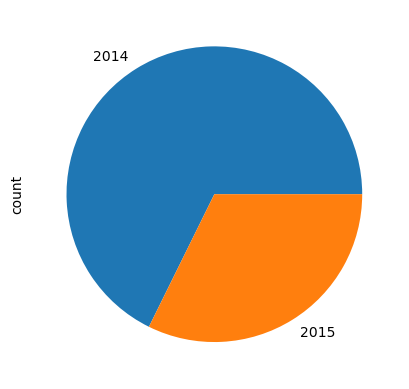

In [23]:
houses['date'].dt.year.value_counts().plot(kind='pie')

In [24]:
houses['date'].dt.month.value_counts()

date
5     2414
4     2231
7     2211
6     2180
8     1940
10    1878
3     1875
9     1774
12    1471
11    1411
2     1250
1      978
Name: count, dtype: int64

<Axes: xlabel='date'>

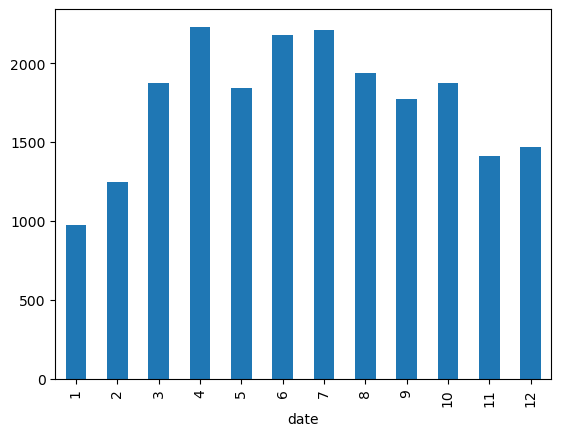

In [30]:
houses[houses.date.between('2014-05-1', '2015-05-1')].date.dt.month.value_counts().sort_index().plot(kind='bar')

In [33]:
houses['date'].dt.day_of_week.value_counts()

date
1    4715
2    4603
0    4099
3    3994
4    3685
5     287
6     230
Name: count, dtype: int64

<Axes: xlabel='week'>

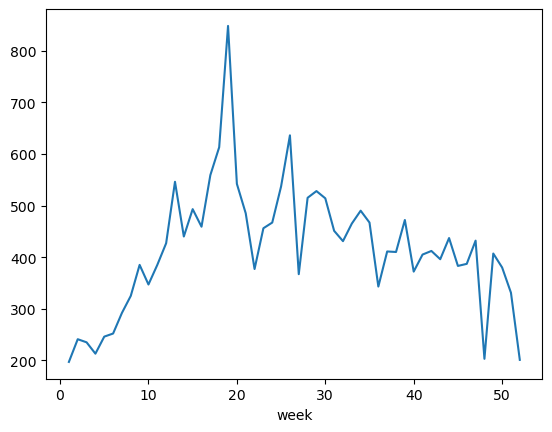

In [61]:
houses['date'].dt.isocalendar().week.value_counts().sort_index().plot()


<Axes: xlabel='date'>

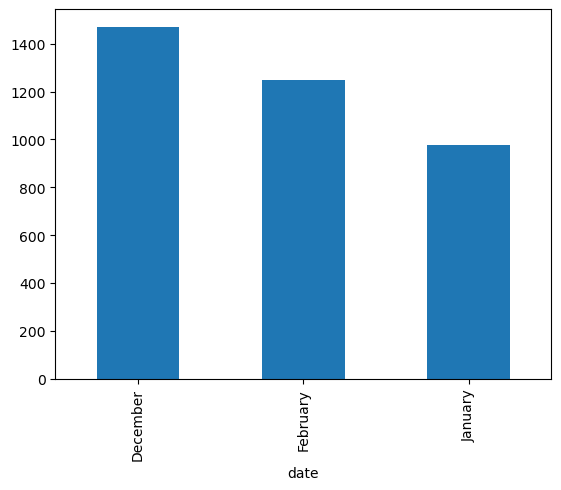

In [46]:
plots = (houses['date'].dt.month == 1) | (houses['date'].dt.month == 12) | (houses['date'].dt.month == 2)
#winter_houses = houses[houses['date'].dt.month.isin([1, 2, 12])]
month_counts = houses[plots]['date'].dt.month_name().value_counts()
month_counts.plot(kind='bar')

<Axes: xlabel='date'>

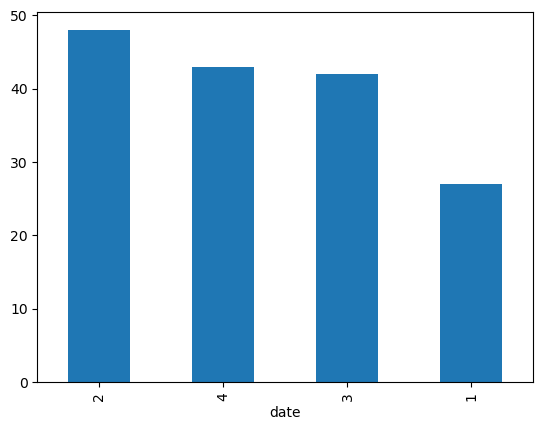

In [54]:
may_one_year = houses[houses.date.between('2014-05-01 00:00:00', '2015-05-01 23:59:59')]
waterfront = may_one_year[may_one_year.waterfront == 1]
waterfront.date.dt.quarter.value_counts().plot(kind='bar')